# MHCflurry + ESMCBA: scoring every design, one shared embedding space

Every design from **19 of the 20 panel structures** (full pMHC+TCR context, 4 models, unique peptides
only) scored with two independent external predictors it has never seen before: **MHCflurry**
(allele-specific neural network ensemble, trained on IEDB binding-affinity data) and **ESMCBA**
(ESM-Cambrian protein language model, fine-tuned per-HLA on binding affinity, this project's own tool).
4MJI is excluded here: its peptide is presented by **HLA-B\*51:01**, not HLA-A\*02:01 like every other
structure in the panel, and both predictors below are single-allele (A\*02:01) models -- scoring a
B\*51:01-restricted peptide against them would be a category error, not just added noise. ESMCBA's
960-dim embeddings for the remaining peptides are reduced to one shared 2D UMAP -- fit jointly over the
whole set, not per model or per structure -- so every subsequent plot below is the *same* layout, just
recolored.

1. Design distribution: across models, across resolution, across recovery
2. The scored table
3. UMAP, 2x3 panel: model / MHCFlurry IC50 / ESMCBA score / hamming to native / MPNN score / anchors
4. Does ESMCBA agree with MHCflurry at all? (sanity check on the two external predictors)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap, BoundaryNorm
from pathlib import Path
from scipy.stats import pearsonr, spearmanr, gaussian_kde, chi2_contingency, fisher_exact, mannwhitneyu

ROOT = Path("/home/ubuntu/if-mhc")
FIG_DIR = ROOT / "figures/fig_panel6_mhcflurry_esmcba_umap"
FIG_DIR.mkdir(exist_ok=True, parents=True)
MODELS = ["vanilla", "noMHC", "ESM-IF1", "LigandMPNN"]
MODEL_COLOR = {"vanilla": "#0072B2", "noMHC": "#E69F00", "ESM-IF1": "#009E73", "LigandMPNN": "#CC79A7"}
MODEL_LABEL = {"vanilla": "ProteinMPNN", "noMHC": "ProteinMPNN (no MHC)", "ESM-IF1": "ESM-IF1",
               "LigandMPNN": "LigandMPNN"}
GRAY = "#B0B0B0"

meta = pd.read_csv(ROOT / "outputs/analysis/panel_unique_peptides_metadata.csv")
mhcflurry = pd.read_csv(ROOT / "outputs/analysis/panel_unique_peptides_mhcflurry.csv")
esmcba = pd.read_csv(ROOT / "outputs/analysis/panel_unique_peptides_esmcba.csv")
df = meta.merge(mhcflurry, on="peptide", how="left").merge(esmcba, on="peptide", how="left")

# every figure below is a score comparison, so a design without both scores is not data.
# A structure is kept only if essentially all of its designs were scored -- a partially
# scored structure would contribute a biased subsample of its own sequence space rather
# than a smaller unbiased one.
def keep_scored(frame, label):
    ok = frame["mhcflurry_ic50_nM"].notna() & frame["esmcba_prediction"].notna()
    cov = ok.groupby(frame["pdb"]).mean()
    drop = set(cov[cov < 0.99].index)
    if drop:
        print(f"{label}: dropping {len(drop)} structure(s) without full score coverage "
              + ", ".join(f"{p} ({cov[p]:.1%})" for p in sorted(drop)))
    return frame[frame["pdb"].isin(cov[cov >= 0.99].index) & ok].reset_index(drop=True)

df = keep_scored(df, "pMHC+TCR")

print(f"{len(df)} (pdb, model, peptide) rows, {df['peptide'].nunique()} distinct peptides, "
     f"{df['pdb'].nunique()} structures")
df.head()

7828 (pdb, model, peptide) rows, 7062 distinct peptides, 40 structures


,pdb,model,peptide,score,native,resolution_A,hamming_to_native,p2_recovered,pomega_recovered,n_anchors_recovered,mhcflurry_ic50_nM,mhcflurry_percentile,esmcba_prediction,UMAP_1,UMAP_2
0,2P5W,vanilla,MLPQYDTPF,0.9547,SLLMWITQC,2.2,7,True,False,1,1429.902247,2.006875,4.331568,13.000988,12.311840
1,2P5W,vanilla,MLPNYFTPF,0.9283,SLLMWITQC,2.2,7,True,False,1,390.770617,1.212000,4.197661,9.843506,9.384629
2,2P5W,vanilla,MLPNYFTRF,0.9868,SLLMWITQC,2.2,7,True,False,1,962.015575,1.722375,4.144500,9.219955,8.146797
3,2P5W,vanilla,MLPNYDTPF,0.9947,SLLMWITQC,2.2,7,True,False,1,1342.396212,1.955375,4.222630,10.181035,9.771833
4,2P5W,vanilla,MLPNWFTPF,0.9704,SLLMWITQC,2.2,6,True,False,1,263.995443,1.017000,4.247863,11.825818,10.804812


## 1. Design distribution: across models, across resolution, across recovery

Unique-design counts per model, unique counts vs. each structure's resolution, and the hamming-distance
(to that structure's own native peptide) distribution per model -- all at the same (pdb, model, unique
peptide) granularity used for the scoring below.

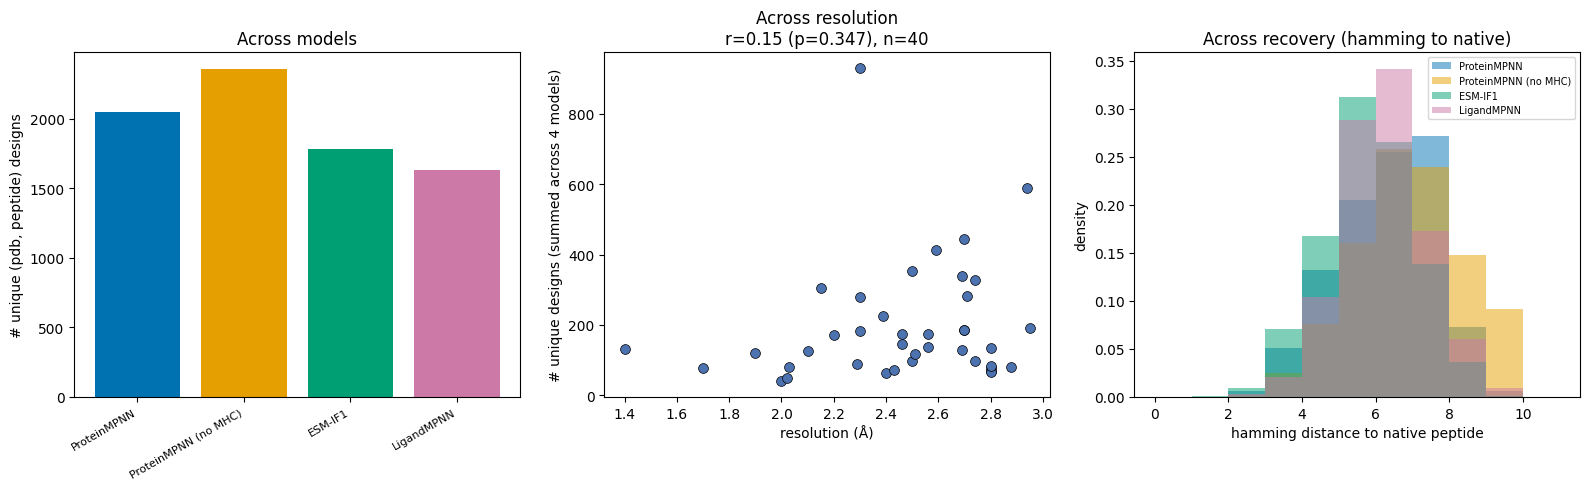

wrote /home/ubuntu/if-mhc/figures/fig_panel6_mhcflurry_esmcba_umap/fig_panel6_design_distributions.png


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

counts = df.groupby("model").size().reindex(MODELS)
axes[0].bar(range(len(MODELS)), counts.values, color=[MODEL_COLOR[m] for m in MODELS])
axes[0].set_xticks(range(len(MODELS)))
axes[0].set_xticklabels([MODEL_LABEL[m] for m in MODELS], rotation=30, ha="right", fontsize=8)
axes[0].set_ylabel("# unique (pdb, peptide) designs")
axes[0].set_title("Across models")

res_counts = df.groupby(["pdb", "resolution_A"]).size().reset_index(name="n_unique")
axes[1].scatter(res_counts["resolution_A"], res_counts["n_unique"], color="#4C72B0", s=50,
               edgecolor="black", linewidth=0.5)
r, p = pearsonr(res_counts["resolution_A"], res_counts["n_unique"])
axes[1].set_xlabel("resolution (Å)")
axes[1].set_ylabel("# unique designs (summed across 4 models)")
axes[1].set_title(f"Across resolution\nr={r:.2f} (p={p:.3f}), n={len(res_counts)}")

for model in MODELS:
    sub = df[df.model == model]
    axes[2].hist(sub["hamming_to_native"], bins=range(0, 12), alpha=0.5, density=True,
                color=MODEL_COLOR[model], label=MODEL_LABEL[model])
axes[2].set_xlabel("hamming distance to native peptide")
axes[2].set_ylabel("density")
axes[2].set_title("Across recovery (hamming to native)")
axes[2].legend(fontsize=7)

fig.tight_layout()
out = FIG_DIR / "fig_panel6_design_distributions.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

## 2. The scored table

In [3]:
df[["pdb", "model", "peptide", "native", "score", "resolution_A", "hamming_to_native",
   "n_anchors_recovered", "mhcflurry_ic50_nM", "esmcba_prediction"]].head(10)

,pdb,model,peptide,native,score,resolution_A,hamming_to_native,n_anchors_recovered,mhcflurry_ic50_nM,esmcba_prediction
0,2P5W,vanilla,MLPQYDTPF,SLLMWITQC,0.9547,2.2,7,1,1429.902247,4.331568
1,2P5W,vanilla,MLPNYFTPF,SLLMWITQC,0.9283,2.2,7,1,390.770617,4.197661
2,2P5W,vanilla,MLPNYFTRF,SLLMWITQC,0.9868,2.2,7,1,962.015575,4.144500
3,2P5W,vanilla,MLPNYDTPF,SLLMWITQC,0.9947,2.2,7,1,1342.396212,4.222630
4,2P5W,vanilla,MLPNWFTPF,SLLMWITQC,0.9704,2.2,6,1,263.995443,4.247863
5,2P5W,vanilla,MLPQYDTPL,SLLMWITQC,1.0075,2.2,7,1,27.972352,2.148924
6,2P5W,vanilla,MLPQYDTRF,SLLMWITQC,0.9835,2.2,7,1,2972.663138,4.254077
7,2P5W,vanilla,MLPQYFTKF,SLLMWITQC,1.0885,2.2,7,1,651.290090,4.301714
8,2P5W,vanilla,MLPNYLTRF,SLLMWITQC,1.0785,2.2,7,1,898.877568,4.224565
9,2P5W,vanilla,MLPNWFTRF,SLLMWITQC,1.0397,2.2,6,1,544.643938,4.185442


## 3. UMAP, 2x3 panel

One shared UMAP layout (fit jointly over all unique peptides' ESMCBA embeddings), recolored six ways.
Where a color variable doesn't apply to a point (ESM-IF1 has no usable per-design score), that point is
grayed out -- solid gray, not a transparent/faded version of the color scale, so "not applicable" is
never confused with "low value".

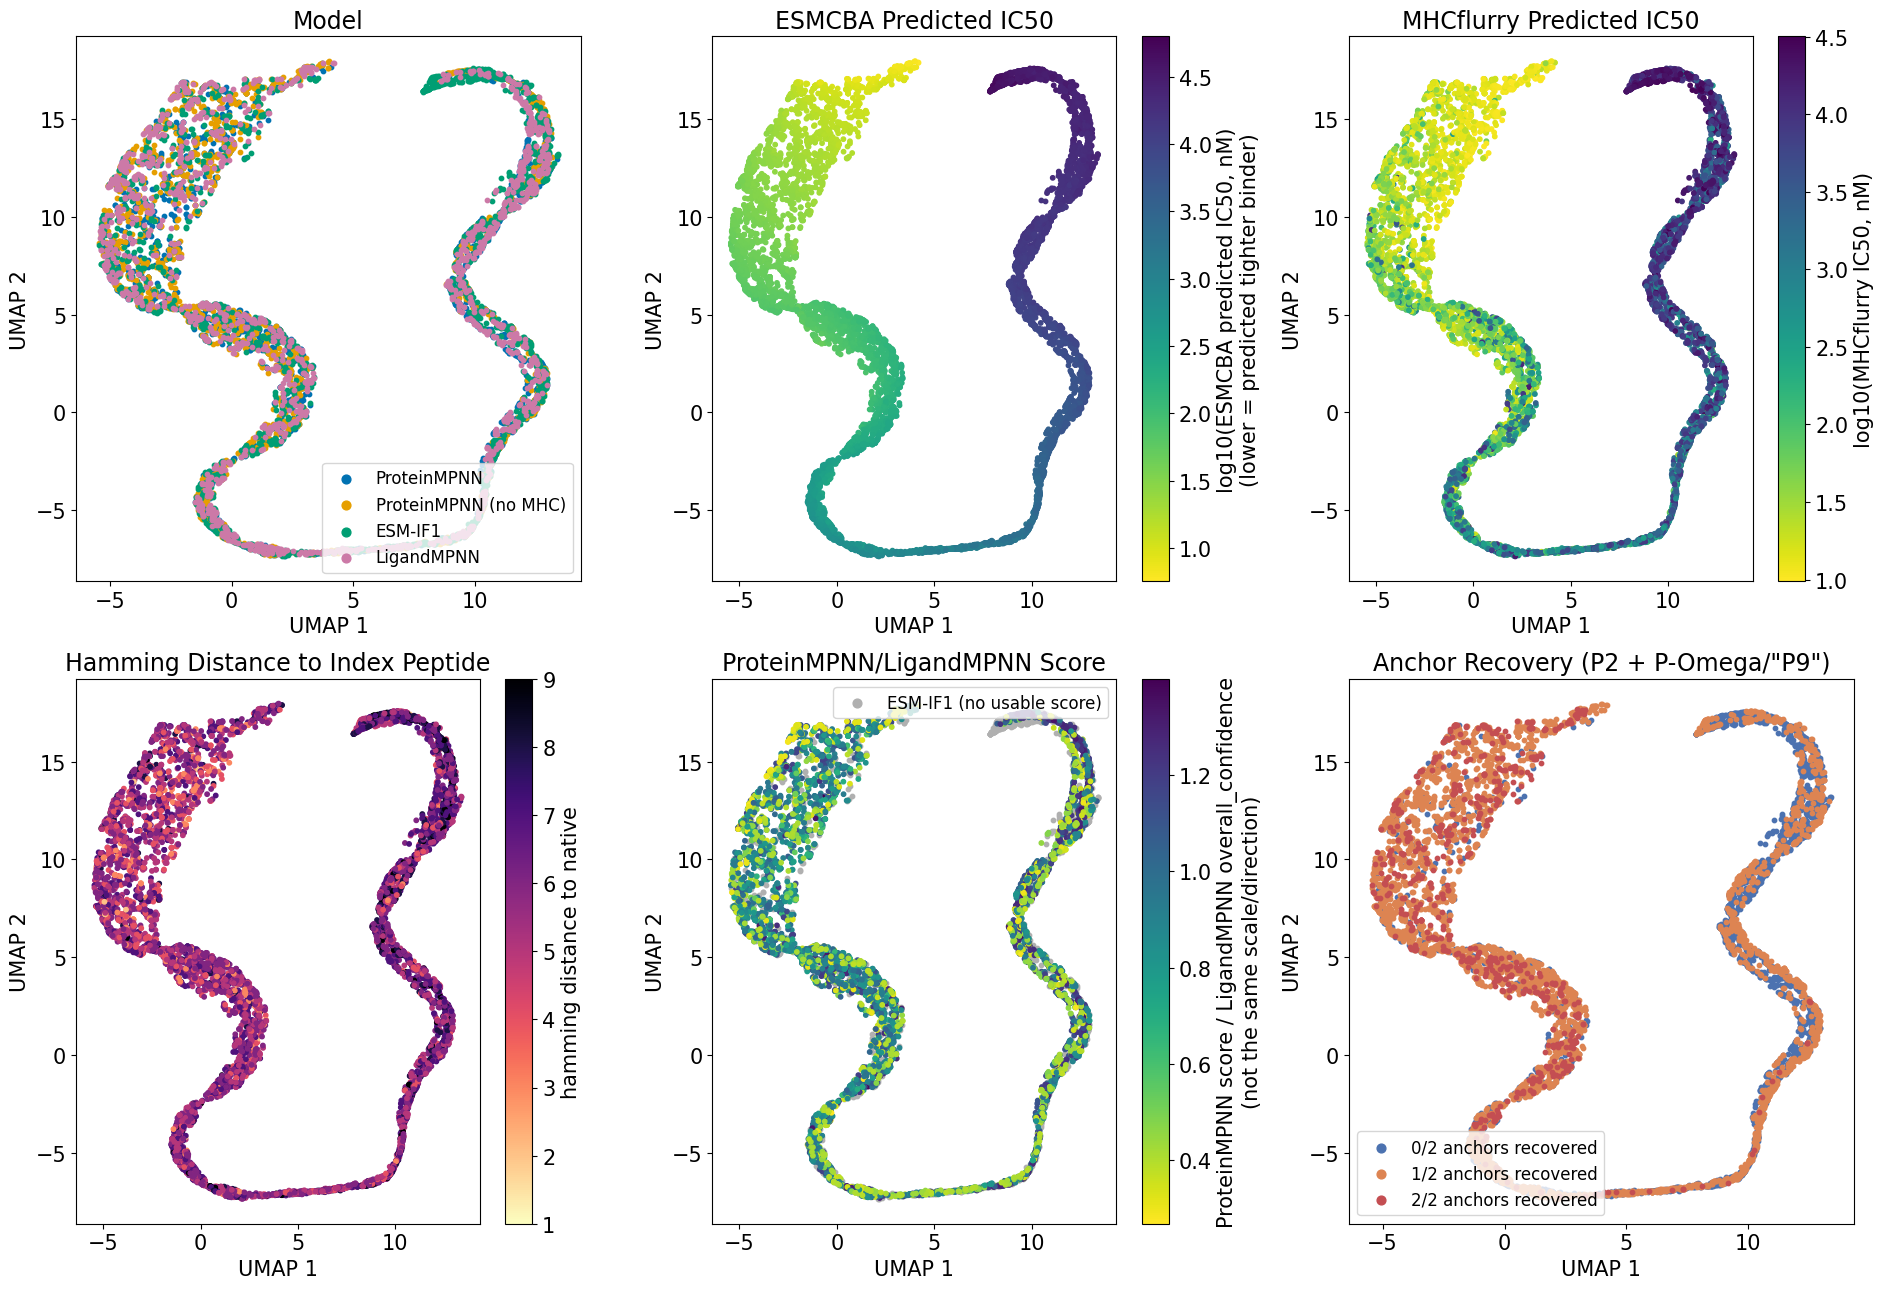

wrote /home/ubuntu/if-mhc/figures/fig_panel6_mhcflurry_esmcba_umap/fig_panel6_umap_2x3.png


In [4]:
TITLE_FS, LABEL_FS, TICK_FS, LEGEND_FS, CBAR_FS = 17, 15, 15, 12, 15
fig, axes = plt.subplots(2, 3, figsize=(19, 13))

# (1) Model
ax = axes[0, 0]
for model in MODELS:
    sub = df[df.model == model]
    ax.scatter(sub["UMAP_1"], sub["UMAP_2"], s=10, color=MODEL_COLOR[model], label=MODEL_LABEL[model])
ax.set_title("Model", fontsize=TITLE_FS)
ax.legend(fontsize=LEGEND_FS, markerscale=2)

# (2) ESMCBA predicted score
ax = axes[0, 1]
sc = ax.scatter(df["UMAP_1"], df["UMAP_2"], s=10, c=df["esmcba_prediction"], cmap="viridis_r")
cb = fig.colorbar(sc, ax=ax, label="log10(ESMCBA predicted IC50, nM)\n(lower = predicted tighter binder)")
cb.ax.tick_params(labelsize=TICK_FS); cb.set_label(cb.ax.get_ylabel(), fontsize=LABEL_FS)
ax.set_title("ESMCBA Predicted IC50", fontsize=TITLE_FS)

# (3) MHCFlurry predicted IC50 (log scale)
ax = axes[0, 2]
sc = ax.scatter(df["UMAP_1"], df["UMAP_2"], s=10, c=np.log10(df["mhcflurry_ic50_nM"]), cmap="viridis_r")
cb = fig.colorbar(sc, ax=ax, label="log10(MHCflurry IC50, nM)")
cb.ax.tick_params(labelsize=TICK_FS); cb.set_label(cb.ax.get_ylabel(), fontsize=LABEL_FS)
ax.set_title("MHCflurry Predicted IC50", fontsize=TITLE_FS)

# (4) Hamming distance to native
ax = axes[1, 0]
sc = ax.scatter(df["UMAP_1"], df["UMAP_2"], s=10, c=df["hamming_to_native"], cmap="magma_r")
cb = fig.colorbar(sc, ax=ax, label="hamming distance to native")
cb.ax.tick_params(labelsize=TICK_FS); cb.set_label(cb.ax.get_ylabel(), fontsize=LABEL_FS)
ax.set_title("Hamming Distance to Index Peptide", fontsize=TITLE_FS)

# (5) ProteinMPNN/LigandMPNN score; ESM-IF1 (no usable score) grayed out
ax = axes[1, 1]
has_score = df["score"].notna()
ax.scatter(df.loc[~has_score, "UMAP_1"], df.loc[~has_score, "UMAP_2"], s=10, color=GRAY,
          label="ESM-IF1 (no usable score)")
sc = ax.scatter(df.loc[has_score, "UMAP_1"], df.loc[has_score, "UMAP_2"], s=10,
               c=df.loc[has_score, "score"], cmap="viridis_r")
cb = fig.colorbar(sc, ax=ax, label="ProteinMPNN score / LigandMPNN overall_confidence\n(not the same scale/direction)")
cb.ax.tick_params(labelsize=TICK_FS); cb.set_label(cb.ax.get_ylabel(), fontsize=LABEL_FS)
ax.set_title("ProteinMPNN/LigandMPNN Score", fontsize=TITLE_FS)
ax.legend(fontsize=LEGEND_FS, markerscale=2, loc="upper right")

# (6) # anchors recovered (P2 + P-Omega/"P9")
ax = axes[1, 2]
anchor_colors = {0: "#4C72B0", 1: "#DD8452", 2: "#C44E52"}
for n_anchor, color in anchor_colors.items():
    sub = df[df.n_anchors_recovered == n_anchor]
    ax.scatter(sub["UMAP_1"], sub["UMAP_2"], s=10, color=color, label=f"{n_anchor}/2 anchors recovered")
ax.set_title("Anchor Recovery (P2 + P-Omega/\"P9\")", fontsize=TITLE_FS)
ax.legend(fontsize=LEGEND_FS, markerscale=2)

for ax in axes.flat:
    ax.set_xlabel("UMAP 1", fontsize=LABEL_FS)
    ax.set_ylabel("UMAP 2", fontsize=LABEL_FS)
    ax.tick_params(axis="both", labelsize=TICK_FS)

fig.tight_layout()
out = FIG_DIR / "fig_panel6_umap_2x3.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

## 4. Does ESMCBA agree with MHCflurry at all?

Two independent predictors (different architectures, different training procedures) scoring the same
peptides for the same allele. Both report log10(predicted IC50, nM), so the standard 500 nM strong-binder
cutoff (log10(500) = 2.70) applies identically to both axes. If they agree, that's real signal about
binding, not an artifact of either model individually -- if they don't, at least one of them isn't
telling us much about this particular peptide set. Broken out per model (2x2) rather than pooled, so the
agreement isn't hiding a case where it only holds for one model's designs -- colored by local point
density (Gaussian KDE), with everything outside the joint 500 nM quadrant (strong by *both* MHCflurry
and ESMCBA) rendered more transparent, so the double-strong-binder population isn't visually swamped by
the much larger pileup that is weak by at least one predictor.

ProteinMPNN: Pearson r=0.862 (p=0.00e+00), Spearman rho=0.864 (p=0.00e+00), n=2047
ProteinMPNN (no MHC): Pearson r=0.927 (p=0.00e+00), Spearman rho=0.921 (p=0.00e+00), n=2363


ESM-IF1: Pearson r=0.827 (p=0.00e+00), Spearman rho=0.833 (p=0.00e+00), n=1783


LigandMPNN: Pearson r=0.895 (p=0.00e+00), Spearman rho=0.871 (p=0.00e+00), n=1635


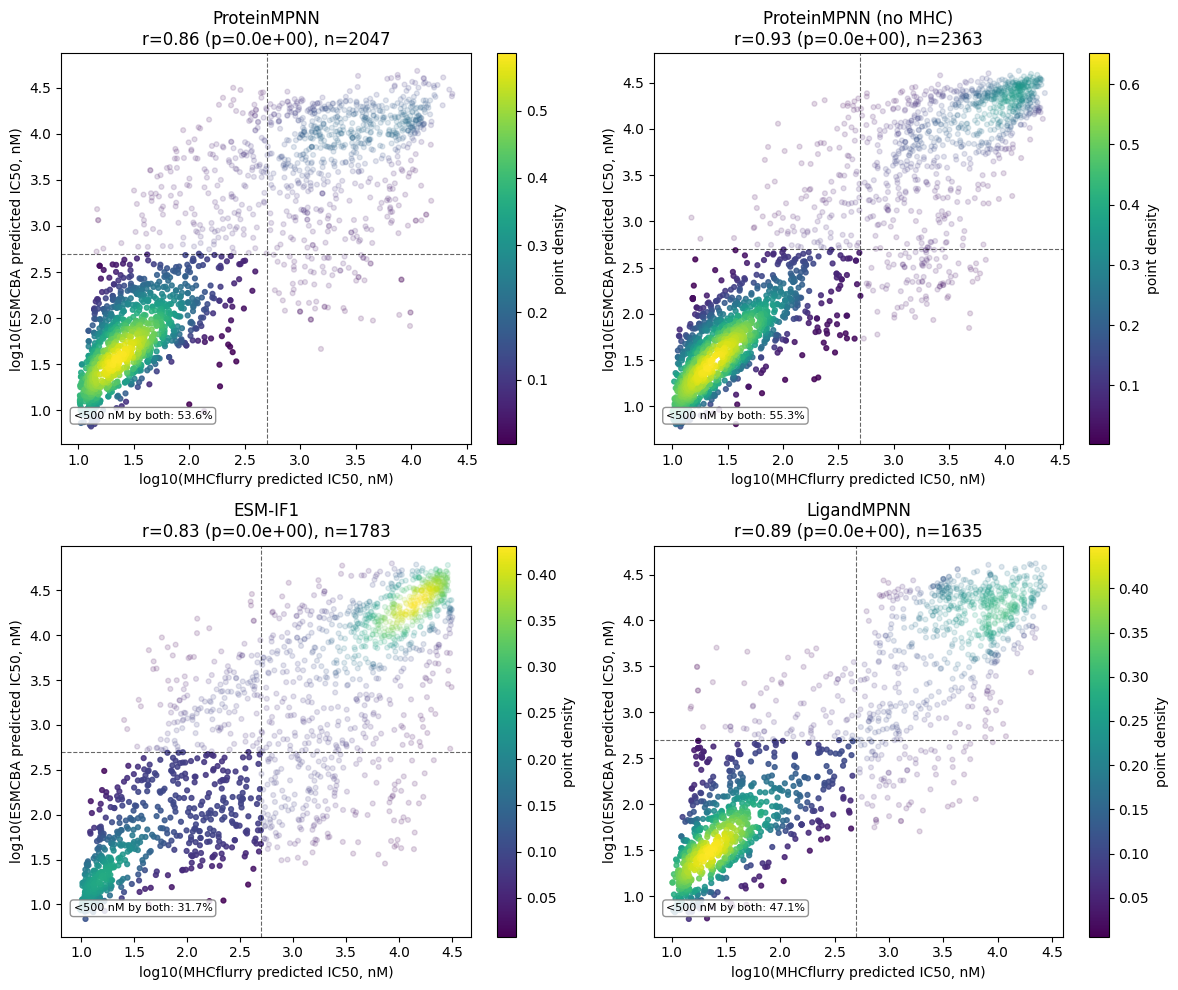

wrote /home/ubuntu/if-mhc/figures/fig_panel6_mhcflurry_esmcba_umap/fig_panel6_esmcba_vs_mhcflurry_by_model.png


In [5]:
LOG500 = np.log10(500)
cmap_density = plt.get_cmap("viridis")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, model in zip(axes.flat, MODELS):
    sub = df[df.model == model]
    r, p = pearsonr(sub["esmcba_prediction"], np.log10(sub["mhcflurry_ic50_nM"]))
    rho, p_rho = spearmanr(sub["esmcba_prediction"], sub["mhcflurry_ic50_nM"])
    print(f"{MODEL_LABEL[model]}: Pearson r={r:.3f} (p={p:.2e}), Spearman rho={rho:.3f} "
         f"(p={p_rho:.2e}), n={len(sub)}")
    x = np.log10(sub["mhcflurry_ic50_nM"].values)
    y = sub["esmcba_prediction"].values
    density = gaussian_kde(np.vstack([x, y]))(np.vstack([x, y]))
    order = np.argsort(density)  # lowest density first, so denser points draw on top
    x, y, density = x[order], y[order], density[order]
    is_double_strong = (x < LOG500) & (y < LOG500)
    norm = plt.Normalize(density.min(), density.max())
    colors = cmap_density(norm(density))
    colors[~is_double_strong, 3] = 0.15
    colors[is_double_strong, 3] = 0.85
    sc = ax.scatter(x, y, c=colors, s=12)
    sm = plt.cm.ScalarMappable(cmap=cmap_density, norm=norm)
    fig.colorbar(sm, ax=ax, label="point density")
    ax.axvline(LOG500, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.axhline(LOG500, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
    pct_double_strong = 100 * np.mean(is_double_strong)
    ax.text(0.03, 0.06, f"<500 nM by both: {pct_double_strong:.1f}%",
           transform=ax.transAxes, fontsize=8, va="bottom", ha="left",
           bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="gray"))
    ax.set_xlabel("log10(MHCflurry predicted IC50, nM)")
    ax.set_ylabel("log10(ESMCBA predicted IC50, nM)")
    ax.set_title(f"{MODEL_LABEL[model]}\nr={r:.2f} (p={p:.1e}), n={len(sub)}")
fig.tight_layout()
out = FIG_DIR / "fig_panel6_esmcba_vs_mhcflurry_by_model.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

## 5. Same, pMHC-only context (no TCR)

Everything above was pMHC+TCR (full) context designs. This repeats the ESMCBA-vs-MHCflurry agreement
check for the pMHC-only design condition -- same 19 structures, same 4 models, same allele, but the
designs themselves come from a much larger and more diverse unique-peptide set (9,190 vs. 3,557), since
removing the TCR from the design context is already established elsewhere in this project to increase
design diversity.

19000 (pdb, model, peptide) rows, 16327 distinct peptides, 40 structures
ProteinMPNN: Pearson r=0.899 (p=0.00e+00), Spearman rho=0.879 (p=0.00e+00), n=6637


ProteinMPNN (no MHC): Pearson r=0.926 (p=0.00e+00), Spearman rho=0.883 (p=0.00e+00), n=4478


ESM-IF1: Pearson r=0.819 (p=0.00e+00), Spearman rho=0.826 (p=0.00e+00), n=3459
LigandMPNN: Pearson r=0.913 (p=0.00e+00), Spearman rho=0.891 (p=0.00e+00), n=4426


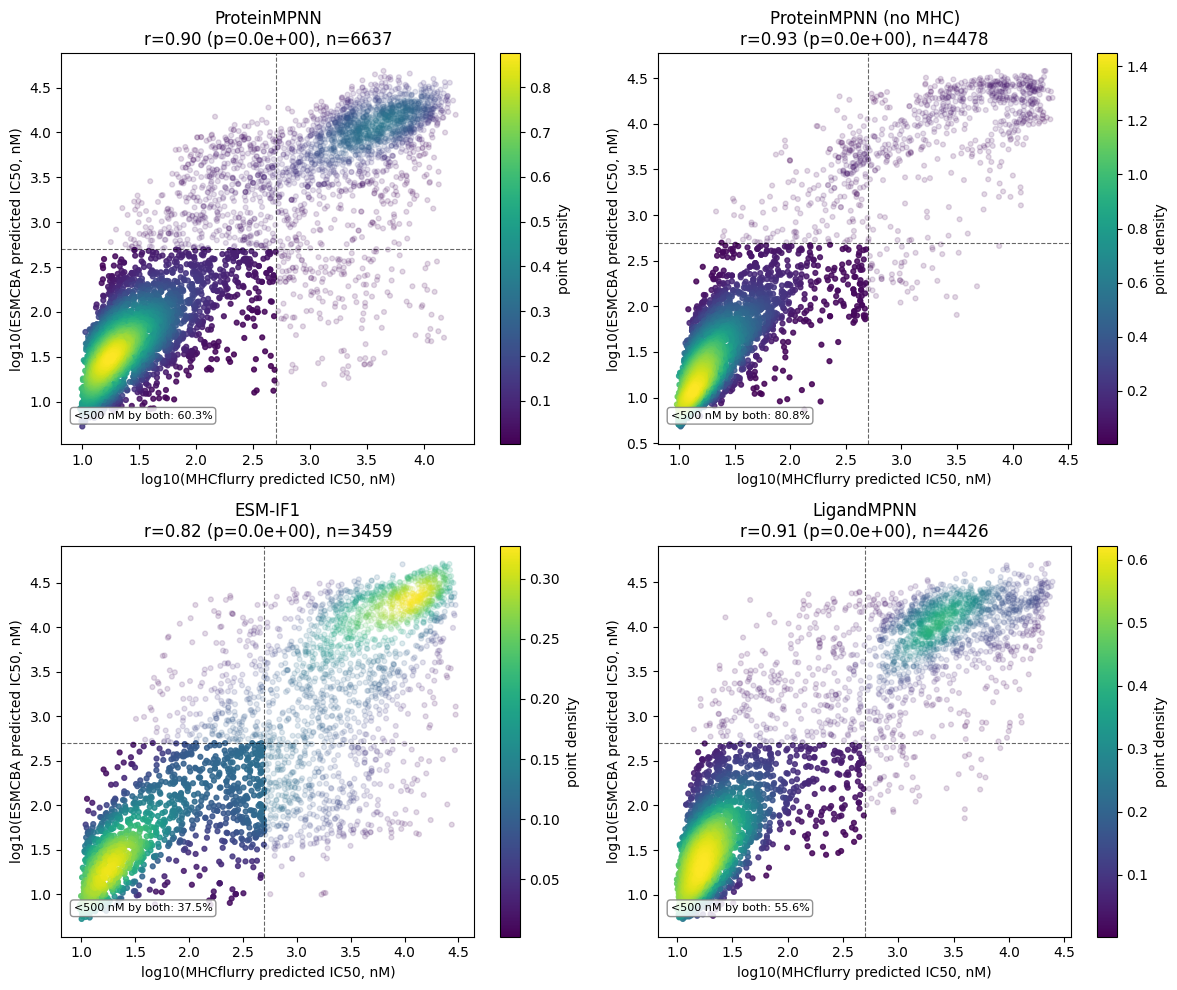

wrote /home/ubuntu/if-mhc/figures/fig_panel6_mhcflurry_esmcba_umap/fig_panel6_esmcba_vs_mhcflurry_by_model_mhconly.png


In [6]:
meta_mhconly = pd.read_csv(ROOT / "outputs/analysis/panel_unique_peptides_metadata_mhconly.csv")
mhcflurry_mhconly = pd.read_csv(ROOT / "outputs/analysis/panel_unique_peptides_mhcflurry_mhconly.csv")
esmcba_mhconly = pd.read_csv(ROOT / "outputs/analysis/panel_unique_peptides_esmcba_mhconly.csv")
df_mhconly = meta_mhconly.merge(mhcflurry_mhconly, on="peptide", how="left").merge(
    esmcba_mhconly, on="peptide", how="left")
df_mhconly = keep_scored(df_mhconly, "pMHC only")
print(f"{len(df_mhconly)} (pdb, model, peptide) rows, {df_mhconly['peptide'].nunique()} distinct "
     f"peptides, {df_mhconly['pdb'].nunique()} structures")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, model in zip(axes.flat, MODELS):
    sub = df_mhconly[df_mhconly.model == model]
    r, p = pearsonr(sub["esmcba_prediction"], np.log10(sub["mhcflurry_ic50_nM"]))
    rho, p_rho = spearmanr(sub["esmcba_prediction"], sub["mhcflurry_ic50_nM"])
    print(f"{MODEL_LABEL[model]}: Pearson r={r:.3f} (p={p:.2e}), Spearman rho={rho:.3f} "
         f"(p={p_rho:.2e}), n={len(sub)}")
    x = np.log10(sub["mhcflurry_ic50_nM"].values)
    y = sub["esmcba_prediction"].values
    density = gaussian_kde(np.vstack([x, y]))(np.vstack([x, y]))
    order = np.argsort(density)   # densest points drawn last
    x, y, density = x[order], y[order], density[order]
    # same quadrant treatment as the full-context figure, so the two are directly comparable
    is_double_strong = (x < LOG500) & (y < LOG500)
    norm = plt.Normalize(density.min(), density.max())
    colors = cmap_density(norm(density))
    colors[~is_double_strong, 3] = 0.15
    colors[is_double_strong, 3] = 0.85
    ax.scatter(x, y, c=colors, s=12)
    sm = plt.cm.ScalarMappable(cmap=cmap_density, norm=norm)
    fig.colorbar(sm, ax=ax, label="point density")
    ax.axvline(LOG500, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.axhline(LOG500, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.text(0.03, 0.06, f"<500 nM by both: {100 * np.mean(is_double_strong):.1f}%",
            transform=ax.transAxes, fontsize=8, va="bottom", ha="left",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="gray"))
    ax.set_xlabel("log10(MHCflurry predicted IC50, nM)")
    ax.set_ylabel("log10(ESMCBA predicted IC50, nM)")
    ax.set_title(f"{MODEL_LABEL[model]}\nr={r:.2f} (p={p:.1e}), n={len(sub)}")
fig.tight_layout()
out = FIG_DIR / "fig_panel6_esmcba_vs_mhcflurry_by_model_mhconly.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

## 6. Which model produces more strong binders (MHCflurry IC50 < 500 nM)?

500 nM is the standard IEDB/NetMHC "binder" threshold, not a cutoff picked for this analysis. Both
structural arms are shown side by side, because the answer is not the same in each: removing the TCR
raises the strong-binder rate, and it does so by different amounts per model, so a single-arm bar
chart would report a model ranking that only holds in one context.

Omnibus test, run separately within each arm: 4x2 contingency table (model x strong/weak), chi-square
test of independence -- does strong-binder rate depend on which model made the design at all?
Follow-up: pairwise Fisher's exact tests between every pair of models, Bonferroni-corrected across all
6 pairs (consistent with how every other multi-way comparison in these notebooks is corrected). A
third test asks, per model, whether that model's own rate shifts between the two arms.

In [7]:
ARMS = [("full", df, "pMHC+TCR"), ("mhconly", df_mhconly, "pMHC only")]
for _, frame, _ in ARMS:
    frame["strong_binder"] = frame["mhcflurry_ic50_nM"] < 500

rates, omnibus = {}, {}
for arm, frame, arm_label in ARMS:
    rt = frame.groupby("model")["strong_binder"].agg(["sum", "count"])
    rt["pct_strong"] = 100 * rt["sum"] / rt["count"]
    rates[arm] = rt.reindex(MODELS)
    print(f"=== {arm_label} ===")
    print(rates[arm].rename(columns={"sum": "n_strong", "count": "n_total"}).to_string())

    contingency = pd.crosstab(frame["model"], frame["strong_binder"]).reindex(MODELS)
    chi2, p_om, dof, _ = chi2_contingency(contingency)
    omnibus[arm] = (chi2, p_om)
    print(f"omnibus chi-square (model x strong/weak): chi2={chi2:.2f}, dof={dof}, p={p_om:.2e}")

    pairs = [(a, b) for i, a in enumerate(MODELS) for b in MODELS[i + 1:]]
    for a, b in pairs:
        odds, p_raw = fisher_exact(contingency.loc[[a, b]].values)
        p_adj = min(1.0, p_raw * len(pairs))
        print(f"  {MODEL_LABEL[a]:22s} vs {MODEL_LABEL[b]:22s}: "
              f"{rates[arm].loc[a, 'pct_strong']:.1f}% vs {rates[arm].loc[b, 'pct_strong']:.1f}%, "
              f"odds_ratio={odds:.2f}, p_bonferroni={p_adj:.2e} "
              f"({'*' if p_adj < 0.05 else 'ns'})")
    print()

# per model, does removing the TCR change that model's own strong-binder rate?
print("=== full vs pMHC only, within model (Fisher's exact, Bonferroni x4) ===")
arm_shift = {}
for m in MODELS:
    f_, mo = rates["full"].loc[m], rates["mhconly"].loc[m]
    table = [[int(f_["sum"]), int(f_["count"] - f_["sum"])],
             [int(mo["sum"]), int(mo["count"] - mo["sum"])]]
    odds, p_raw = fisher_exact(table)
    p_adj = min(1.0, p_raw * len(MODELS))
    arm_shift[m] = p_adj
    print(f"  {MODEL_LABEL[m]:22s} {f_['pct_strong']:.1f}% -> {mo['pct_strong']:.1f}% "
          f"(delta {mo['pct_strong'] - f_['pct_strong']:+.1f} pp), "
          f"p_bonferroni={p_adj:.2e} ({'*' if p_adj < 0.05 else 'ns'})")

=== pMHC+TCR ===
            n_strong  n_total  pct_strong
model                                    
vanilla         1300     2047   63.507572
noMHC           1424     2363   60.262378
ESM-IF1          726     1783   40.717891
LigandMPNN       853     1635   52.171254
omnibus chi-square (model x strong/weak): chi2=238.50, dof=3, p=2.01e-51
  ProteinMPNN            vs ProteinMPNN (no MHC)  : 63.5% vs 60.3%, odds_ratio=0.87, p_bonferroni=1.65e-01 (ns)
  ProteinMPNN            vs ESM-IF1               : 63.5% vs 40.7%, odds_ratio=0.39, p_bonferroni=1.29e-44 (*)
  ProteinMPNN            vs LigandMPNN            : 63.5% vs 52.2%, odds_ratio=0.63, p_bonferroni=2.95e-11 (*)
  ProteinMPNN (no MHC)   vs ESM-IF1               : 60.3% vs 40.7%, odds_ratio=0.45, p_bonferroni=6.27e-35 (*)
  ProteinMPNN (no MHC)   vs LigandMPNN            : 60.3% vs 52.2%, odds_ratio=0.72, p_bonferroni=2.40e-06 (*)
  ESM-IF1                vs LigandMPNN            : 40.7% vs 52.2%, odds_ratio=1.59, p_bonferroni=1.23

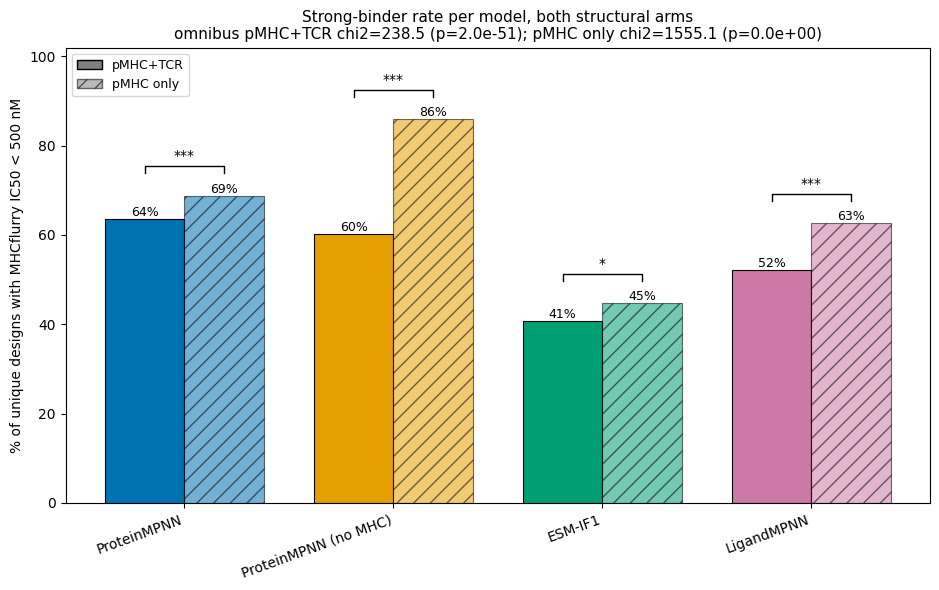

wrote /home/ubuntu/if-mhc/figures/fig_panel6_mhcflurry_esmcba_umap/fig_panel6_strong_binder_rate_by_model.png


In [8]:
def stars(p):
    return "***" if p < 1e-3 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"

fig, ax = plt.subplots(figsize=(9.5, 6))
x = np.arange(len(MODELS)); width = 0.38
for k, (arm, _, arm_label) in enumerate(ARMS):
    vals = rates[arm]["pct_strong"].values
    bars = ax.bar(x + (k - 0.5) * width, vals, width,
                  color=[MODEL_COLOR[m] for m in MODELS],
                  alpha=1.0 if arm == "full" else 0.55,
                  edgecolor="black", linewidth=0.8,
                  hatch="" if arm == "full" else "//",
                  label=arm_label)
    for b, v in zip(bars, vals):
        ax.annotate(f"{v:.0f}%", (b.get_x() + b.get_width() / 2, b.get_height()),
                    ha="center", va="bottom", fontsize=9)

# bracket per model for the full -> mhconly shift
top = max(rates[a]["pct_strong"].max() for a, _, _ in ARMS)
for i, m in enumerate(MODELS):
    y = max(rates["full"].loc[m, "pct_strong"], rates["mhconly"].loc[m, "pct_strong"]) + 5
    ax.plot([i - width / 2, i - width / 2, i + width / 2, i + width / 2],
            [y, y + 1.6, y + 1.6, y], lw=1.0, color="black")
    ax.text(i, y + 2.2, stars(arm_shift[m]), ha="center", va="bottom", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels([MODEL_LABEL[m] for m in MODELS], rotation=20, ha="right")
ax.set_ylabel("% of unique designs with MHCflurry IC50 < 500 nM")
ax.set_ylim(0, top + 16)
ax.set_title("Strong-binder rate per model, both structural arms\n"
             f"omnibus pMHC+TCR chi2={omnibus['full'][0]:.1f} (p={omnibus['full'][1]:.1e}); "
             f"pMHC only chi2={omnibus['mhconly'][0]:.1f} (p={omnibus['mhconly'][1]:.1e})",
             fontsize=11)
handles = [plt.Rectangle((0, 0), 1, 1, facecolor="grey", edgecolor="black", alpha=1.0),
           plt.Rectangle((0, 0), 1, 1, facecolor="grey", edgecolor="black", alpha=0.55, hatch="//")]
ax.legend(handles, [a[2] for a in ARMS], fontsize=9, loc="upper left")
fig.tight_layout()
out = FIG_DIR / "fig_panel6_strong_binder_rate_by_model.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

## 7. Does removing the TCR (mhconly) shift the predicted-affinity distribution?

Per model, full (pMHC+TCR) vs. mhconly (no TCR) -- same unique-peptide-level MHCflurry/ESMCBA scores
already computed above, now compared as two distributions rather than one pooled scatter. Unpaired
(the two conditions produce different peptide sets, not matched pairs), Mann-Whitney U per model for
both predictors.

ProteinMPNN, log10(MHCflurry IC50, nM): full mean=2.26 (n=2047), mhconly mean=2.11 (n=6637), Mann-Whitney p=6.04e-14
ProteinMPNN, ESMCBA predicted score: full mean=2.64 (n=2047), mhconly mean=2.45 (n=6637), Mann-Whitney p=3.81e-16
ProteinMPNN (no MHC), log10(MHCflurry IC50, nM): full mean=2.38 (n=2363), mhconly mean=1.68 (n=4478), Mann-Whitney p=3.18e-179
ProteinMPNN (no MHC), ESMCBA predicted score: full mean=2.61 (n=2363), mhconly mean=1.89 (n=4478), Mann-Whitney p=1.08e-145
ESM-IF1, log10(MHCflurry IC50, nM): full mean=2.93 (n=1783), mhconly mean=2.76 (n=3459), Mann-Whitney p=4.68e-10
ESM-IF1, ESMCBA predicted score: full mean=3.04 (n=1783), mhconly mean=2.78 (n=3459), Mann-Whitney p=5.75e-15


LigandMPNN, log10(MHCflurry IC50, nM): full mean=2.57 (n=1635), mhconly mean=2.19 (n=4426), Mann-Whitney p=1.02e-41
LigandMPNN, ESMCBA predicted score: full mean=2.75 (n=1635), mhconly mean=2.58 (n=4426), Mann-Whitney p=4.99e-10


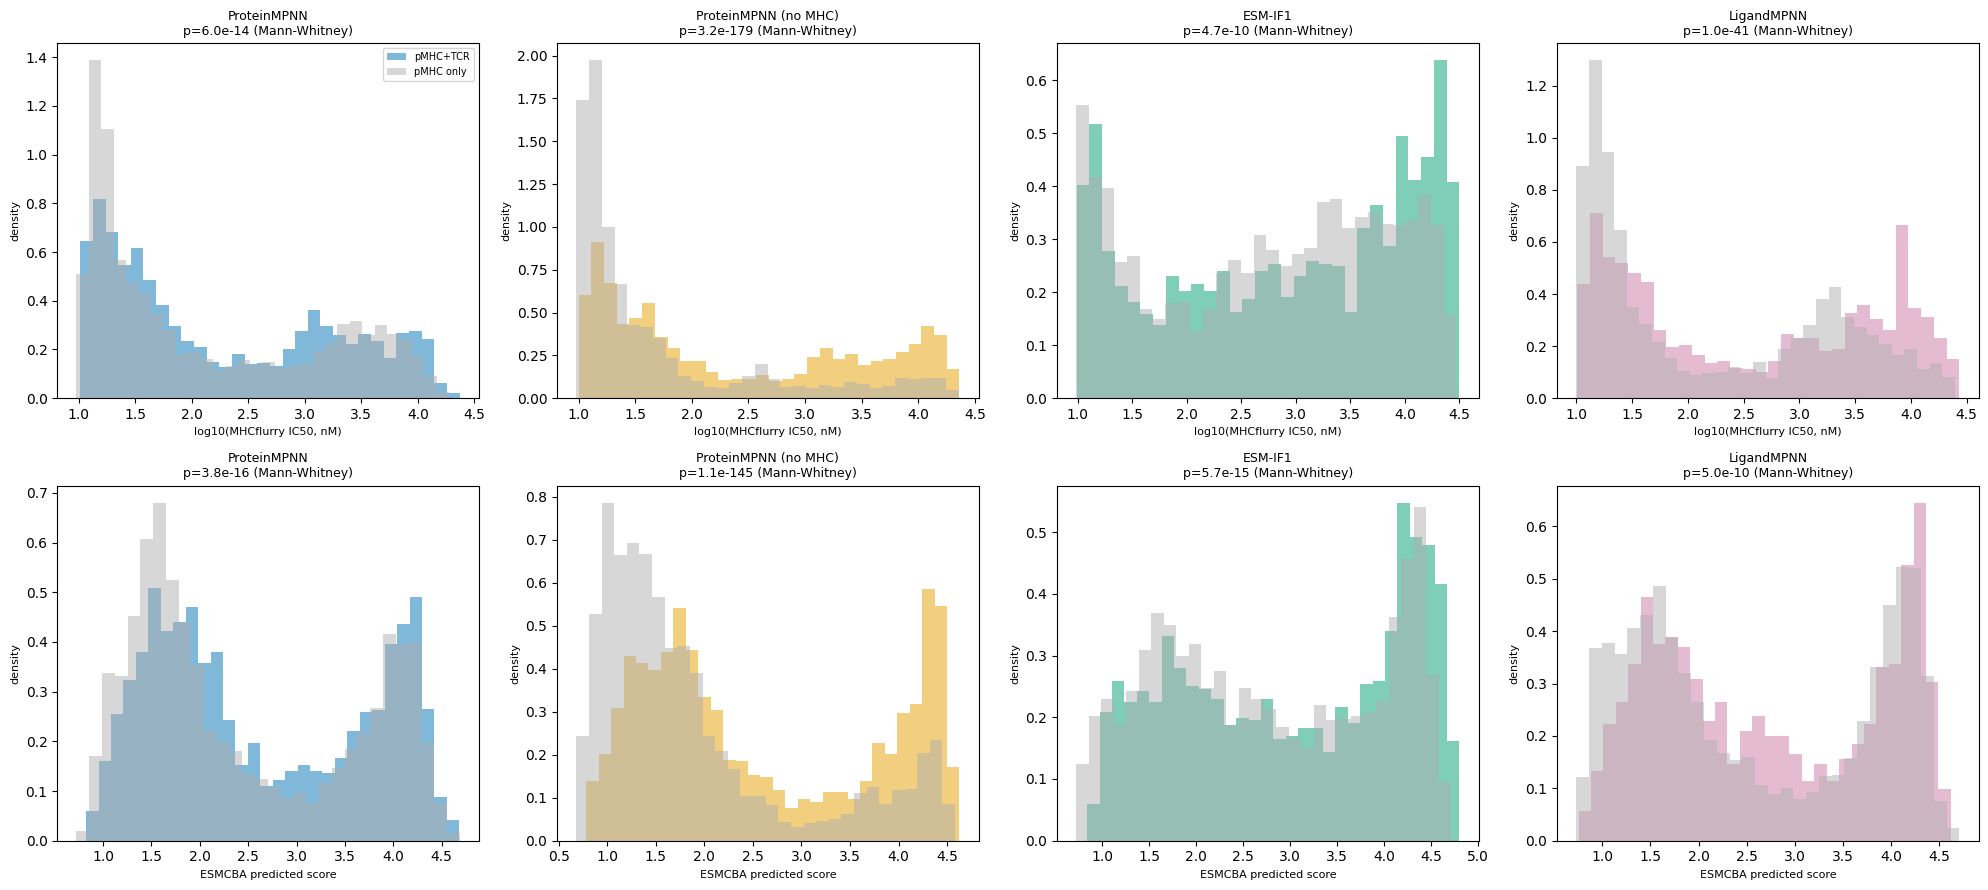

wrote /home/ubuntu/if-mhc/figures/fig_panel6_mhcflurry_esmcba_umap/fig_panel6_full_vs_mhconly_affinity_shift.png


In [9]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for col, model in enumerate(MODELS):
    full_sub = df[df.model == model]
    mhconly_sub = df_mhconly[df_mhconly.model == model]

    for row, (col_name, xlabel, transform) in enumerate([
        ("mhcflurry_ic50_nM", "log10(MHCflurry IC50, nM)", np.log10),
        ("esmcba_prediction", "ESMCBA predicted score", lambda v: v),
    ]):
        ax = axes[row, col]
        full_vals = transform(full_sub[col_name].dropna().values)
        mhconly_vals = transform(mhconly_sub[col_name].dropna().values)
        stat, p = mannwhitneyu(full_vals, mhconly_vals, alternative="two-sided")
        ax.hist(full_vals, bins=30, alpha=0.5, density=True, color=MODEL_COLOR[model], label="pMHC+TCR")
        ax.hist(mhconly_vals, bins=30, alpha=0.5, density=True, color=GRAY, label="pMHC only")
        ax.set_xlabel(xlabel, fontsize=8)
        ax.set_ylabel("density", fontsize=8)
        ax.set_title(f"{MODEL_LABEL[model]}\np={p:.1e} (Mann-Whitney)", fontsize=9)
        if row == 0 and col == 0:
            ax.legend(fontsize=7)
        print(f"{MODEL_LABEL[model]}, {xlabel}: full mean={full_vals.mean():.2f} "
             f"(n={len(full_vals)}), mhconly mean={mhconly_vals.mean():.2f} (n={len(mhconly_vals)}), "
             f"Mann-Whitney p={p:.2e}")
fig.tight_layout()
out = FIG_DIR / "fig_panel6_full_vs_mhconly_affinity_shift.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

## 8. Does removing the TCR shift the models' *own* design scores?

Sections 6-7 use two external predictors that never saw these designs during training. Here we ask a
different question: does each model's *own* score for its own designs (ProteinMPNN/ProteinMPNN-no-MHC
average per-residue negative log-likelihood -- lower is more confident; LigandMPNN overall_confidence --
higher is more confident) shift when the TCR is removed? ESM-IF1 has no usable per-design score and is
excluded. Pooled across every scored structure (unpaired, Mann-Whitney U per model), then broken out
per structure (Bonferroni-corrected across them) to see whether a pooled shift is uniform or
concentrated in a subset of structures.

Pooled across all structures:
  ProteinMPNN: full mean=0.990 (n=2047), mhconly mean=1.239 (n=6637), Mann-Whitney p=0.00e+00
  ProteinMPNN (no MHC): full mean=0.974 (n=2363), mhconly mean=1.094 (n=4478), Mann-Whitney p=6.63e-147
  LigandMPNN: full mean=0.407 (n=1635), mhconly mean=0.316 (n=4426), Mann-Whitney p=0.00e+00


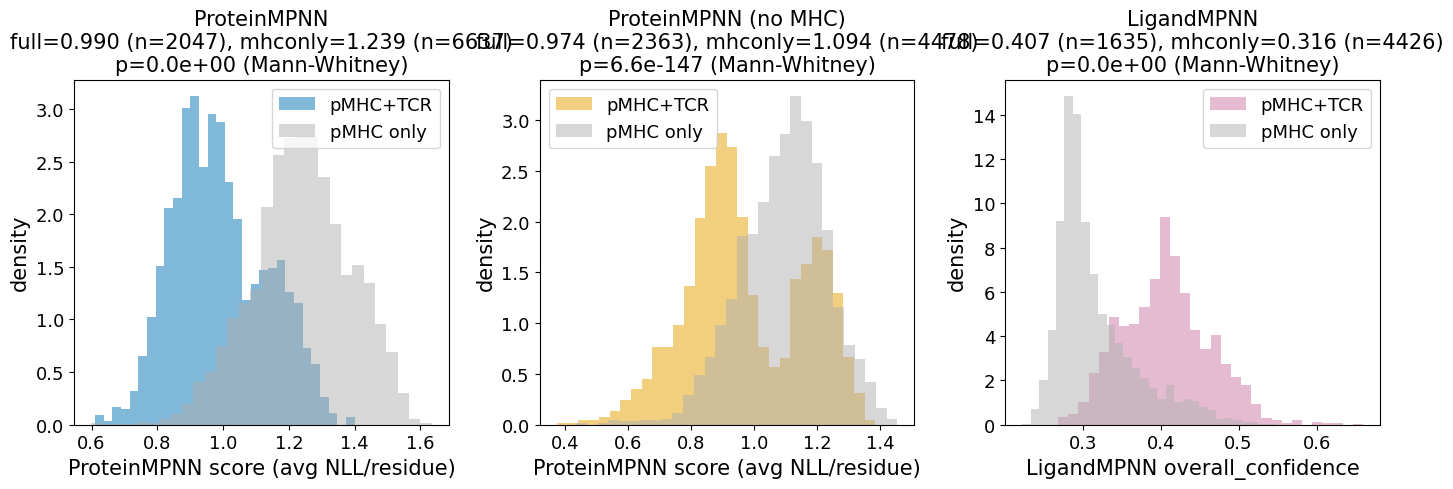

wrote /home/ubuntu/if-mhc/figures/fig_panel6_mhcflurry_esmcba_umap/fig_panel6_own_score_shift_pooled.png


In [10]:
score_full = meta[["pdb", "model", "score"]].dropna()
score_mhconly = meta_mhconly[["pdb", "model", "score"]].dropna()
SCORE_MODELS = ["vanilla", "noMHC", "LigandMPNN"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5.0))
print("Pooled across all structures:")
for ax, model in zip(axes, SCORE_MODELS):
    fv = score_full.loc[score_full.model == model, "score"].values
    mv = score_mhconly.loc[score_mhconly.model == model, "score"].values
    stat, p = mannwhitneyu(fv, mv, alternative="two-sided")
    ax.hist(fv, bins=30, alpha=0.5, density=True, color=MODEL_COLOR[model], label="pMHC+TCR")
    ax.hist(mv, bins=30, alpha=0.5, density=True, color=GRAY, label="pMHC only")
    xlabel = "LigandMPNN overall_confidence" if model == "LigandMPNN" else "ProteinMPNN score (avg NLL/residue)"
    ax.set_xlabel(xlabel, fontsize=15)
    ax.set_ylabel("density", fontsize=15)
    ax.tick_params(labelsize=13)
    ax.set_title(f"{MODEL_LABEL[model]}\nfull={fv.mean():.3f} (n={len(fv)}), mhconly={mv.mean():.3f} "
                f"(n={len(mv)})\np={p:.1e} (Mann-Whitney)", fontsize=15)
    ax.legend(fontsize=13)
    print(f"  {MODEL_LABEL[model]}: full mean={fv.mean():.3f} (n={len(fv)}), "
         f"mhconly mean={mv.mean():.3f} (n={len(mv)}), Mann-Whitney p={p:.2e}")
fig.tight_layout()
out = FIG_DIR / "fig_panel6_own_score_shift_pooled.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

Per-structure (Bonferroni n=40):
  ProteinMPNN: 33 significant, 7 not significant, 0 skipped (n<5) out of 40 structures
  ProteinMPNN (no MHC): 32 significant, 7 not significant, 1 skipped (n<5) out of 40 structures


  LigandMPNN: 29 significant, 6 not significant, 5 skipped (n<5) out of 40 structures


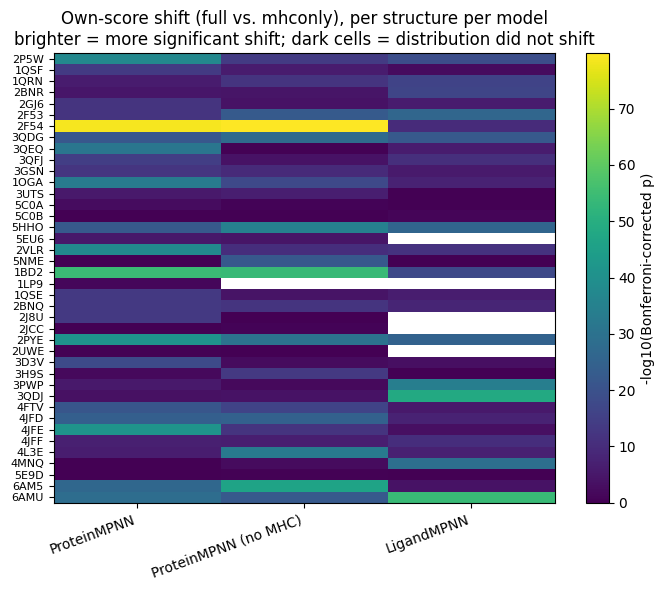

wrote /home/ubuntu/if-mhc/figures/fig_panel6_mhcflurry_esmcba_umap/fig_panel6_own_score_shift_by_structure.png


In [11]:
STRUCTS_SCORE = [p for p in meta["pdb"].unique() if p != "4MJI"]
n_structs = len(STRUCTS_SCORE)
sig_matrix = pd.DataFrame(index=STRUCTS_SCORE, columns=SCORE_MODELS, dtype=float)
print(f"Per-structure (Bonferroni n={n_structs}):")
for model in SCORE_MODELS:
    n_sig, n_ns, n_skip = 0, 0, 0
    for pdb in STRUCTS_SCORE:
        fv = score_full.loc[(score_full.model == model) & (score_full.pdb == pdb), "score"].values
        mv = score_mhconly.loc[(score_mhconly.model == model) & (score_mhconly.pdb == pdb), "score"].values
        if len(fv) < 5 or len(mv) < 5:
            sig_matrix.loc[pdb, model] = np.nan
            n_skip += 1
            continue
        stat, p = mannwhitneyu(fv, mv, alternative="two-sided")
        p_adj = min(1.0, p * n_structs)
        sig_matrix.loc[pdb, model] = p_adj
        if p_adj < 0.05:
            n_sig += 1
        else:
            n_ns += 1
    print(f"  {MODEL_LABEL[model]}: {n_sig} significant, {n_ns} not significant, "
         f"{n_skip} skipped (n<5) out of {n_structs} structures")

fig, ax = plt.subplots(figsize=(7, 6))
sig_display = -np.log10(sig_matrix.astype(float))
im = ax.imshow(sig_display.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(SCORE_MODELS)))
ax.set_xticklabels([MODEL_LABEL[m] for m in SCORE_MODELS], rotation=20, ha="right")
ax.set_yticks(range(n_structs))
ax.set_yticklabels(STRUCTS_SCORE, fontsize=8)
fig.colorbar(im, ax=ax, label="-log10(Bonferroni-corrected p)")
ax.set_title("Own-score shift (full vs. mhconly), per structure per model\nbrighter = more significant "
            "shift; dark cells = distribution did not shift")
fig.tight_layout()
out = FIG_DIR / "fig_panel6_own_score_shift_by_structure.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")